In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom

#### Sampling a single RW

In [2]:
N_step = 10**3           # Number of steps (n)
x = np.zeros(N_step)    # Array of zeros
x[0] = 0                # Add inititial condition
p = 0.5                 # Right jump probability
                        # left jump is trivially q = 1- p

# We first generate the sequence of random numbers Z_n 
# This optimizes the runtime of the code
rndm_seq = np.random.uniform(size=N_step)

for n in range(1, N_step):
    # This is not optimized, especially if have to loop
    # Over different realizations. We will see how this is improved when sampling an ensemble 
    # To statistically describe RWs.
    if (rndm_seq[n] < p):
        x[n] = x[n-1] + 1
    else:
        x[n] = x[n-1] - 1

print("RW generated!")

RW generated!


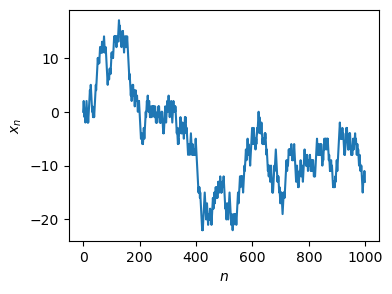

In [3]:
# We may plot the trajectory now
plt.figure(figsize=(4,3))

plt.plot(x, marker = 'none')

plt.xlabel(r'$n$')
plt.ylabel(r'$x_n$')
plt.show()

#### Generating an ensemble of RW

In [4]:
N = 10**3               # Number of steps (n)
p = 0.5                 # Right jump probability
                        # left jump is trivially q = 1- p
R = 10**4               # Number of repetitions

In [5]:
x = np.zeros((R, N)) # Generating the arrows
x[:,0] = 1 # initial price of the asset S_0 = 1

for n in range(1,N):
    trials = np.random.uniform(size=R)
    x[trials<=p,n] = x[trials<=p,n-1] + 1   # If trial <= p then step to the right
    x[trials>p ,n] = x[trials>p ,n-1] - 1   # If trial  > p then step to the left

print("RWs generated!")

RWs generated!


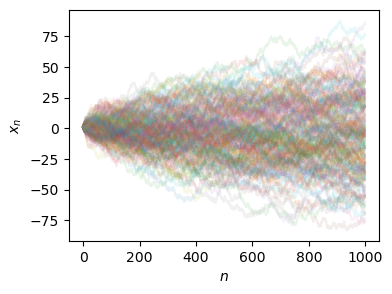

In [6]:
# Plotting different trajectories.
plt.figure(figsize=(4,3))

for i in range(0,200):
    plt.plot(x[i], marker = 'none', alpha=0.1)

plt.xlabel(r'$n$')
plt.ylabel(r'$x_n$')
plt.show()

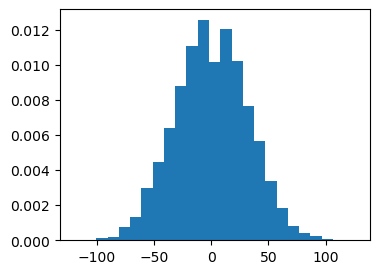

In [7]:
# Plot
plt.figure(figsize=(4,3))

# Positions at last step
x_last = x[:,-1]
plt.hist(x_last, density = True, bins = 25)


plt.show()

The final position can be written in terms of the numbr of steps to the right, which is binomially distributed, $X_N = 2N_+ - N$. We transform the data following $N_+ = \frac{N+x_N}{2}$. We also draw $N_{+} \sim \text{Bin}(N,p)$

In [8]:
print(x[:,-1])

[  2. -28. -16. ...  32.   4.  20.]


In [9]:
N_plus_last = 0.5*(x[:,-1] + N)
print(N_plus_last)

[501. 486. 492. ... 516. 502. 510.]


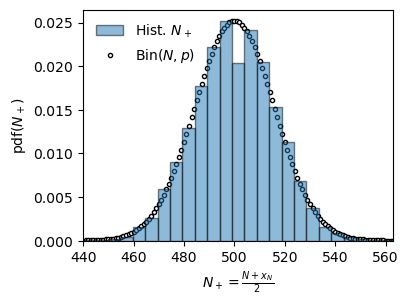

In [10]:
# Plot
plt.figure(figsize=(4,3))

# Positions at last step
plt.hist(N_plus_last, density = True, bins = 25, zorder=10, alpha = 0.5, edgecolor='black', label = r'Hist. $N_+$')

# Plotting the binomial B(N,p)
x_range = np.arange(0, N+1)
binom_dist = binom.pmf(x_range, N, p)
# plt.stem(x_range, binom_dist, use_line_collection=False, basefmt=" ")
plt.plot(x_range, binom_dist, marker = '.', linestyle='none', color='black', markerfacecolor='white', label = r'Bin$(N,p)$')

plt.xlabel(r'$N_+ = \frac{N + x_N}{2}$')
plt.ylabel(r'pdf$(N_+)$')
plt.xlim([np.min(N_plus_last), np.max(N_plus_last)])
plt.legend(loc = 'upper left', frameon=False)
plt.show()

#### Sampling different $p$'s

In [11]:
N = 10**3               # Number of steps (n)
R = 10**4               # Number of repetitions

p_list = [0.5, 0.55, 0.65]

In [12]:
last_positions_p = []    # Keep the last position vector for every value of p
for i,p in enumerate(p_list):
    # Generating ensemble of RWs
    x = np.zeros((R, N)) # Generating the arrows
    x[:,0] = 1 # initial price of the asset S_0 = 1
    
    for n in range(1,N):
        trials = np.random.uniform(size=R)
        x[trials<=p,n] = x[trials<=p,n-1] + 1   # If trial <= p then step to the right
        x[trials>p ,n] = x[trials>p ,n-1] - 1   # If trial  > p then step to the left
    
    print(f"RWs generated!: {i+1}/{len(p_list)}")

    # Statistical description of last position
    x_last = x[:,-1]
    last_positions_p.append(x_last)

RWs generated!: 1/3
RWs generated!: 2/3
RWs generated!: 3/3


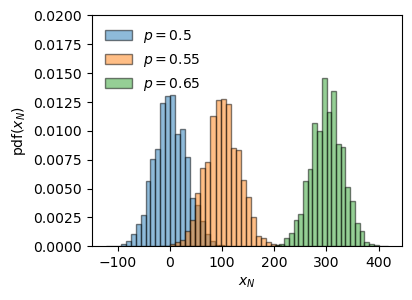

In [13]:
# Plot
plt.figure(figsize=(4,3))

# Positions at last step
for i, x_N_p in enumerate(last_positions_p):
    plt.hist(x_N_p, density = True, bins = 25, alpha = 0.5, edgecolor='black', label = fr'$p={p_list[i]}$')

plt.xlabel(r'$x_N$')
plt.ylabel(r'pdf$(x_N)$')
plt.ylim([0,0.02])
plt.legend(loc = 'upper left', frameon=False)
plt.show()

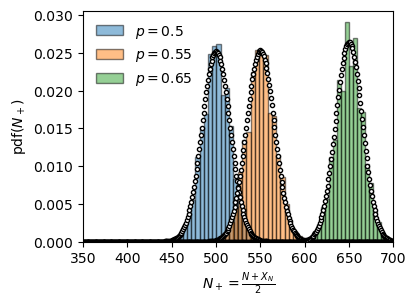

In [14]:
# Plot
plt.figure(figsize=(4,3))

# Positions at last step
for i, x_N_p in enumerate(last_positions_p):
    N_plus = 0.5*(N+x_N_p)
    plt.hist(N_plus, density = True, bins = 25, alpha = 0.5, edgecolor='black', label = fr'$p={p_list[i]}$')
    # Binomial
    x_range = np.arange(0, N+1)
    binom_dist = binom.pmf(x_range, N, p_list[i])
    plt.plot(x_range, binom_dist, marker = '.', linestyle='none', color='black', markerfacecolor='white')

plt.xlabel(r'$N_+ = \frac{N+X_N}{2}$')
plt.ylabel(r'pdf$(N_+)$')
plt.xlim([350,700])
plt.legend(loc = 'upper left', frameon=False)
plt.show()

#### Mean and variance

In [15]:
# Start at p = 0.5
p = 0.5                 # Right jump probability
                        # left jump is trivially q = 1- p
R = 10**5               # Number of repetitions
N = 10**3               # Number of steps

In [16]:
# Generating ensemble of RWs
x = np.zeros((R, N)) # Generating the arrows
x[:,0] = 0 

for n in range(1,N):
    trials = np.random.uniform(size=R)
    x[trials<=p,n] = x[trials<=p,n-1] + 1   # If trial <= p then step to the right
    x[trials>p ,n] = x[trials>p ,n-1] - 1   # If trial  > p then step to the left

print(f"RWs generated!")
# Compute mean and standard deviation
mean_n = np.mean(x, axis = 0) 
std_n = np.std(x, axis = 0)

RWs generated!


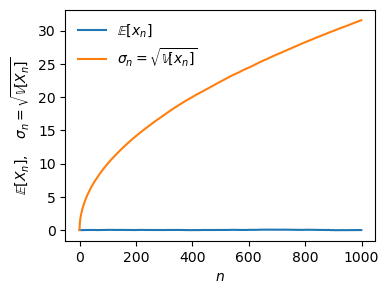

In [17]:
# Plot
plt.figure(figsize=(4,3))

plt.plot(mean_n, marker = 'none', markerfacecolor = 'none', label = r'$\mathbb{E}[x_n]$')
plt.plot(std_n, marker = 'none', markerfacecolor = 'none', label = r'$\sigma_n = \sqrt{\mathbb{V}[x_n]}$')
    

plt.xlabel(r'$n$')
plt.ylabel(r'$\mathbb{E}[X_n], \quad \sigma_n = \sqrt{\mathbb{V}[X_n]}$')
# plt.xlim([-50,50])
plt.legend(loc = 'upper left', frameon=False)
plt.show()